## Titanic - Sobreviveria ou Não

Dataset: Kaggle Titanic Competition
Objetivo: Prever se um passageiro sobreviveu (1) ou não (0)

In [327]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report



In [328]:
train = pd.read_csv('train.csv') #dados para treino
test = pd.read_csv('test.csv') #dados para teste (sem a coluna 'Survived')

In [329]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [330]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [331]:
train.info() #tipo de dados e contagem de valores não nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [332]:
train.describe() #estatísticas descritivas para colunas numéricas

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [333]:
test.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [334]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [335]:
#Preenchendo os valores faltantes de 'Age' com a mediana da coluna, melhor que a média, para evitar impacto de outliers.
train ['Age']=train['Age'].fillna(train['Age'].median())
test['Age']=test['Age'].fillna(test['Age'].median())

In [336]:
#Convertendo coluna 'Sex' para valores numéricos: 0 para masculino e 1 para feminino. Para conseguir fazer o ML.
train['Sex'] = train['Sex'].map({'male': 0, 'female': 1})
test['Sex'] = test['Sex'].map({'male': 0, 'female': 1})
test['Sex'].describe()

count    418.000000
mean       0.363636
std        0.481622
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Sex, dtype: float64

<Axes: xlabel='Sex', ylabel='Survived'>

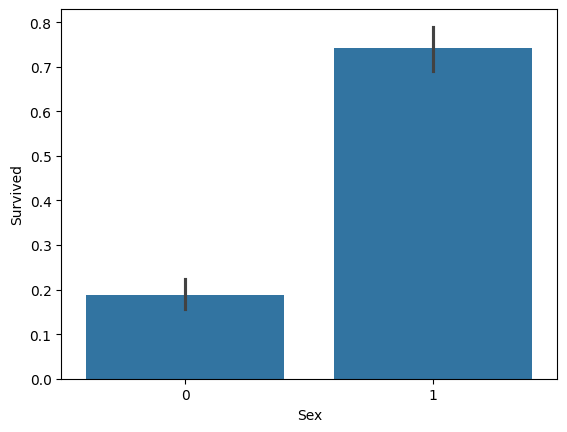

In [337]:
sns.barplot(x='Sex', y='Survived', data=train)

É possível notar que as mulheres sobreviveram muito mais.

Text(0, 0.5, 'Taxa de Sobrevivência')

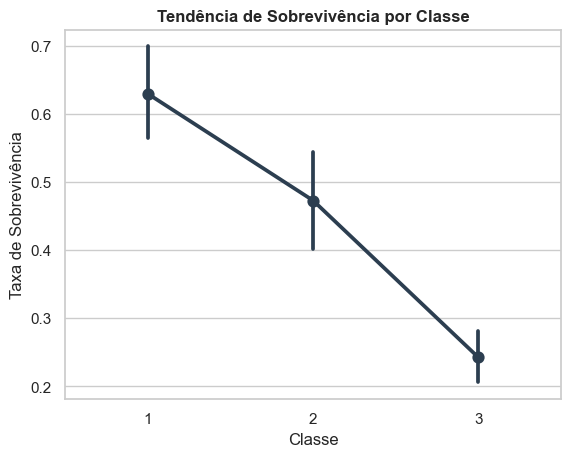

In [358]:
sns.pointplot(x='Pclass', y='Survived', data=train, color='#2c3e50')

plt.title('Tendência de Sobrevivência por Classe', fontweight='bold')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência')

Passageiros na 1 classe sobreviveram quase 2x a mais que a 3 classe

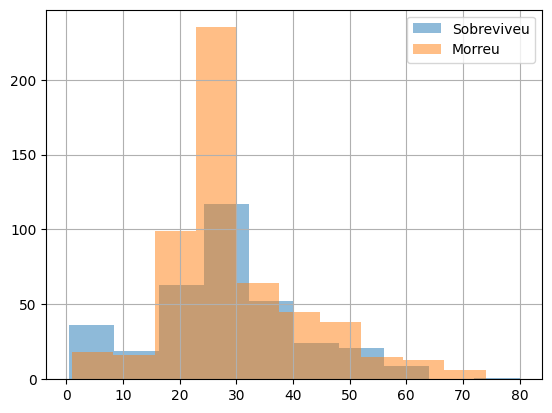

In [339]:
train[train['Survived']==1]['Age'].hist(alpha=0.5, label='Sobreviveu')
train[train['Survived']==0]['Age'].hist(alpha=0.5, label='Morreu')
plt.legend()

Quanto mais velho mais a chance de sobrevivência é menor.

In [340]:
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
test['Embarked'] = test['Embarked'].fillna(test['Embarked'].mode()[0])

# Encoding: S=0, C=1, Q=2
train['Embarked'] = train['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
test['Embarked'] = test['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

In [341]:
#Remoção de colunas que não serão usadas no modelo
cols_para_remover = ['Name', 'Ticket', 'Cabin']
train = train.drop(columns=cols_para_remover)
test = test.drop(columns=cols_para_remover)

In [342]:
# Features escolhidas: classe, sexo e idade (maior impacto na sobrevivência)
features = ['Pclass', 'Sex', 'Age']
X_train = train[features]
Y_train = train['Survived']

# 80% para treinar, 20% para avaliar
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.2, random_state=42)

In [343]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Text(0.5, 1.0, 'Importância das Features')

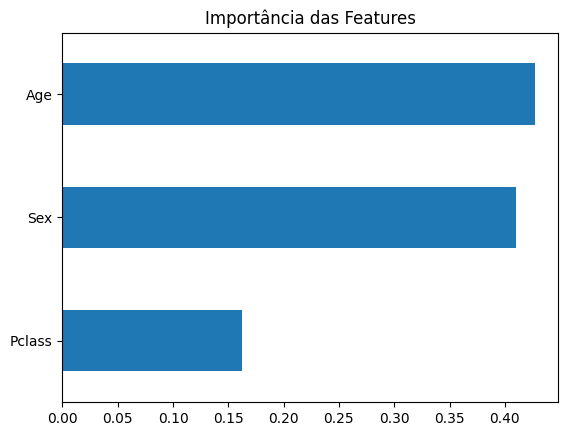

In [344]:
importances = pd.Series(modelo.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title('Importância das Features')

In [345]:
#Avaliação do modelo na base de validação (20%)
previsoes_val = modelo.predict(X_val)
accuracy = accuracy_score(Y_val, previsoes_val)
print(f"Acurácia na validação: {accuracy*100:.0f}%")

Acurácia na validação: 79%


In [346]:
classification_report(Y_val, previsoes_val, target_names=['Morreu', 'Sobreviveu'])

'              precision    recall  f1-score   support\n\n      Morreu       0.80      0.86      0.83       105\n  Sobreviveu       0.78      0.70      0.74        74\n\n    accuracy                           0.79       179\n   macro avg       0.79      0.78      0.78       179\nweighted avg       0.79      0.79      0.79       179\n'

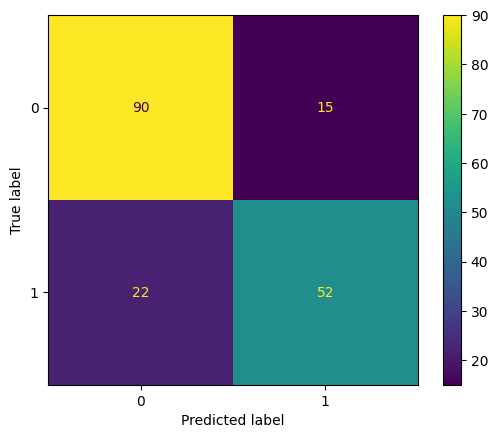

In [347]:
#Matriz de confusão para avaliar o desempenho do modelo
ConfusionMatrixDisplay.from_estimator(modelo, X_val, Y_val)

O modelo é pessimista, prefere errar que o passageiro morreu mas está vivo, comparado a dizer que o passageiro está vivo mas morreu. 

In [349]:
# Teste com passageiros fictícios para ver o que o modelo prevê:
# Passageiro 1: 1 classe, Mulher, 5 anos
# Passageiro 2: 3 Classe, Homem, 35 anos
meus_passageiros = pd.DataFrame({
    'Pclass': [1, 3],
    'Sex': [1, 0], 
    'Age': [5, 35]
})

# Pedindo para o modelo prever
resultado = modelo.predict(meus_passageiros)

resultado

array([1, 0])

## Conclusão:

O modelo Random Forest com as features Pclass, Sex e Age atingiu **79% de acurácia** 
na base de validação.

**Principais aprendizados:**
- A idade foi a feature mais importante
- Classe social teve grande impacto: passageiros da 1ª classe sobreviveram até 2x mais que os da 3ª
- O modelo tem dificuldade com sobreviventes (recall 66%) — esperado dado o desbalanceamento do dataset

**Possíveis melhorias:**
- Adicionar features como SibSp, Parch e Fare
- Experimentar outros algoritmos como XGBoost ou LightGBM